In [1]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

4350


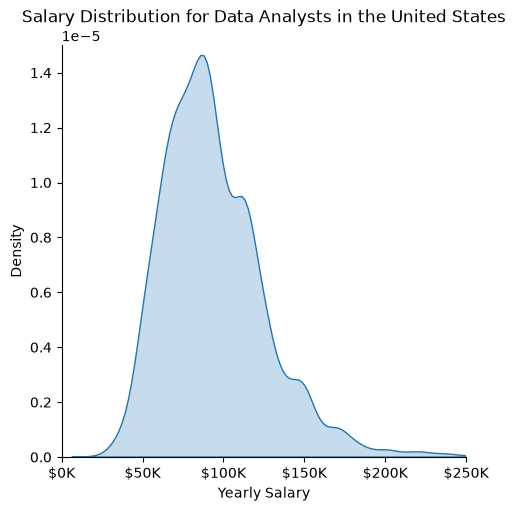

In [38]:
Needed = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()



Needed = Needed[Needed['salary_year_avg'].notna()]

print(len(Needed))   



sns.displot(data = Needed, x='salary_year_avg', kind = 'kde', fill = True)
plt.xlim(0, 250000)     

plt.ylim(0, 1.5e-5)
ax = plt.gca()

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))

plt.title('Salary Distribution for Data Analysts in the United States')
plt.xlabel('Yearly Salary')
plt.ylabel('Density')
plt.show()

276
